In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
from scipy.stats import poisson
import matplotlib.gridspec as gridspec
import scipy.stats as stats
import scipy
import os
import re

pd.set_option('display.max_columns', None)


sns.set_style('ticks', rc={"axes.facecolor": (0, 0, 0, 0)})
sns.set_context('talk')

from matplotlib import rcParams
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial']
import matplotlib.ticker as ticker

In [58]:
genome_sizes = {
    'kpneumo': 5.5,
    'ecoli': 5,
    'paeruginosa': 6.5
}

In [59]:
df = pd.read_csv("../../data/paeruginosa/paeruginosa_data_2023.tsv", sep="\t")

In [60]:
def add_sampling_date(df1, df2, reference_id="Reference", reference_date=""):
    """
    Merges df1 with df2 to add a 'samplingdate' column to df1 based on matching 'ID' in df1 with 'sampleid' in df2.
    
    Parameters:
    df1 (pd.DataFrame): The first dataframe containing 'ID' column.
    df2 (pd.DataFrame): The second dataframe containing 'sampleid' and 'samplingdate' columns.
    
    Returns:
    pd.DataFrame: A new dataframe with the 'samplingdate' column added to df1.
    """
    df = df1.merge(df2[['sampleid', 'samplingdate']], left_on='ID', right_on='sampleid', how='left').drop(columns=['sampleid'])
    
    # Assign reference date if ID matches reference_id
    df.loc[df['ID'] == reference_id, 'samplingdate'] = reference_date
    
    return df

In [61]:
pa_2 = "2019-11-16"
pa_13 = "2020-05-27"
pa_44 = "2019-12-19"
pa_4 = "2020-05-10"
pa_125 = "2019-12-09"
pa_33 = "2020-01-24"
pa_135 = "2020-01-23"
pa_3 = "2020-05-23"
pa_138 = "2020-08-02"
pa_25 = "2020-02-07"
pa_18 = "2019-11-04"
pa_286 = "2020-11-16"

In [62]:
pa_125_968cea793b64f872a9d813a7221b4d13 = pd.read_csv("../../data/paeruginosa/125_968cea793b64f872a9d813a7221b4d13/core.txt", sep="\t")
#pa_135_0edc34b6e11974bd92edd07a11793763 = pd.read_csv("../../data/paeruginosa/135_0edc34b6e11974bd92edd07a11793763/cor")
pa_13_83518f6ba53abf533c1f11f416f218db = pd.read_csv("../../data/paeruginosa/13_83518f6ba53abf533c1f11f416f218db/core.txt", sep="\t")
#pa_138_9a18dcaead24a56d3266d069f4e0a0cd = pd.read_csv("../../data/paeruginosa/138_9a18dcaead24a56d3266d069f4e0a0cd/")
pa_18_9c7c577b31a5c4aa46d0ba1679fda007 = pd.read_csv("../../data/paeruginosa/18_9c7c577b31a5c4aa46d0ba1679fda007/core.txt", sep="\t")
pa_25_b5cef22fb4523d7c5b8e9400a6786244 = pd.read_csv("../../data/paeruginosa/25_b5cef22fb4523d7c5b8e9400a6786244/core.txt", sep="\t")
pa_2_84aeb0f053ee5813f9fa5cc7a13713da = pd.read_csv("../../data/paeruginosa/2_84aeb0f053ee5813f9fa5cc7a13713da/core.txt", sep="\t")
pa_286_65bbcd9ce8ff0208a699f23146f8d1b3 = pd.read_csv("../../data/paeruginosa/286_65bbcd9ce8ff0208a699f23146f8d1b3/core.txt", sep="\t")
pa_33_dbf477aeacef9c3e28261443163caa24 = pd.read_csv("../../data/paeruginosa/33_dbf477aeacef9c3e28261443163caa24/core.txt", sep="\t")
pa_3_d53ebeed867721d29bb3f0032db17eae = pd.read_csv("../../data/paeruginosa/3_d53ebeed867721d29bb3f0032db17eae/core.txt", sep="\t")
pa_44_bb6f9259f5c49bb17de2c65eae3dc3f6 = pd.read_csv("../../data/paeruginosa/44_bb6f9259f5c49bb17de2c65eae3dc3f6/core.txt", sep="\t")
pa_4_ab6d45059415c33f7ff3e26a496f21ab = pd.read_csv("../../data/paeruginosa/4_ab6d45059415c33f7ff3e26a496f21ab/core.txt", sep="\t")
pa_4_d36af9c8f081724a0ee235c91dd1c098 = pd.read_csv("../../data/paeruginosa/4_d36af9c8f081724a0ee235c91dd1c098/core.txt", sep="\t")
pa_4_e006ae4eb2e972865cbd2ea06b3ef5dd = pd.read_csv("../../data/paeruginosa/4_e006ae4eb2e972865cbd2ea06b3ef5dd/core.txt", sep="\t")

In [63]:
pa_125_968cea793b64f872a9d813a7221b4d13 = add_sampling_date(pa_125_968cea793b64f872a9d813a7221b4d13, df, reference_date=pa_125)
pa_13_83518f6ba53abf533c1f11f416f218db = add_sampling_date(pa_13_83518f6ba53abf533c1f11f416f218db, df, reference_date=pa_13)
pa_18_9c7c577b31a5c4aa46d0ba1679fda007 = add_sampling_date(pa_18_9c7c577b31a5c4aa46d0ba1679fda007, df, reference_date=pa_18)
pa_25_b5cef22fb4523d7c5b8e9400a6786244 = add_sampling_date(pa_25_b5cef22fb4523d7c5b8e9400a6786244, df, reference_date=pa_25)
pa_2_84aeb0f053ee5813f9fa5cc7a13713da = add_sampling_date(pa_2_84aeb0f053ee5813f9fa5cc7a13713da, df, reference_date=pa_2)
pa_286_65bbcd9ce8ff0208a699f23146f8d1b3 = add_sampling_date(pa_286_65bbcd9ce8ff0208a699f23146f8d1b3, df, reference_date=pa_286)
pa_33_dbf477aeacef9c3e28261443163caa24 = add_sampling_date(pa_33_dbf477aeacef9c3e28261443163caa24, df, reference_date=pa_33)
pa_3_d53ebeed867721d29bb3f0032db17eae = add_sampling_date(pa_3_d53ebeed867721d29bb3f0032db17eae, df, reference_date=pa_3)
pa_44_bb6f9259f5c49bb17de2c65eae3dc3f6 = add_sampling_date(pa_44_bb6f9259f5c49bb17de2c65eae3dc3f6, df, reference_date=pa_44)
pa_4_ab6d45059415c33f7ff3e26a496f21ab = add_sampling_date(pa_4_ab6d45059415c33f7ff3e26a496f21ab, df, reference_date=pa_4)
pa_4_d36af9c8f081724a0ee235c91dd1c098 = add_sampling_date(pa_4_d36af9c8f081724a0ee235c91dd1c098, df, reference_date=pa_4)
pa_4_e006ae4eb2e972865cbd2ea06b3ef5dd = add_sampling_date(pa_4_e006ae4eb2e972865cbd2ea06b3ef5dd, df, reference_date=pa_4)

In [64]:
dataset_dict = {
    "pa_125_968cea793b64f872a9d813a7221b4d13":pa_125_968cea793b64f872a9d813a7221b4d13,
    "pa_13_83518f6ba53abf533c1f11f416f218db":pa_13_83518f6ba53abf533c1f11f416f218db,
    "pa_18_9c7c577b31a5c4aa46d0ba1679fda007":pa_18_9c7c577b31a5c4aa46d0ba1679fda007,
    "pa_25_b5cef22fb4523d7c5b8e9400a6786244":pa_25_b5cef22fb4523d7c5b8e9400a6786244,
    "pa_2_84aeb0f053ee5813f9fa5cc7a13713da":pa_2_84aeb0f053ee5813f9fa5cc7a13713da,
    "pa_286_65bbcd9ce8ff0208a699f23146f8d1b3":pa_286_65bbcd9ce8ff0208a699f23146f8d1b3,
    "pa_33_dbf477aeacef9c3e28261443163caa24":pa_33_dbf477aeacef9c3e28261443163caa24,
    "pa_3_d53ebeed867721d29bb3f0032db17eae":pa_3_d53ebeed867721d29bb3f0032db17eae,
    "pa_44_bb6f9259f5c49bb17de2c65eae3dc3f6":pa_44_bb6f9259f5c49bb17de2c65eae3dc3f6,
    "pa_4_ab6d45059415c33f7ff3e26a496f21ab":pa_4_ab6d45059415c33f7ff3e26a496f21ab,
    "pa_4_e006ae4eb2e972865cbd2ea06b3ef5dd":pa_4_e006ae4eb2e972865cbd2ea06b3ef5dd,
    "pa_4_d36af9c8f081724a0ee235c91dd1c098":pa_4_d36af9c8f081724a0ee235c91dd1c098
}

In [65]:
def compute_snps_per_day(dataset_dict):
    """
    Computes the SNPs per day for each sample in each dataset provided in the dataset dictionary.
    
    Parameters:
    dataset_dict (dict): Dictionary where keys are dataset names and values are corresponding DataFrames.
    
    Returns:
    pd.DataFrame: Output DataFrame with columns ["dataset_name", "sampleid", "snps/day"].
    """
    # Initialize list to store output data
    output_data = []

    # Iterate through each dataset in the dictionary
    for dataset_name, df in dataset_dict.items():
        # Convert sampling date to datetime
        df = df.copy()
        df["samplingdate"] = pd.to_datetime(df["samplingdate"])
        
        # Identify the reference sample (the one with zero SNPs, assuming "Reference" is labeled)
        reference_row = df[df["VARIANT"] == 0]
        if reference_row.empty:
            continue  # Skip dataset if no reference sample found

        # Get the reference date (earliest sample date with zero SNPs)
        reference_date = reference_row["samplingdate"].min()

        # Filter out the reference row
        df_filtered = df[df["VARIANT"] > 0]

        # Compute days since reference for each sample
        df_filtered["days_since_ref"] = (df_filtered["samplingdate"] - reference_date).dt.days

        # Compute SNPs per day
        df_filtered["snps_per_day"] = df_filtered["VARIANT"] / df_filtered["days_since_ref"]

        # Replace infinite values (division by zero) and drop NaNs
        df_filtered.replace([np.inf, -np.inf], np.nan, inplace=True)
        df_filtered.dropna(subset=["snps_per_day"], inplace=True)

        # Append results to output list
        output_data.extend(df_filtered[["ID", "snps_per_day"]].assign(dataset_name=dataset_name).values)

    # Convert results to DataFrame
    output_df = pd.DataFrame(output_data, columns=["sampleid", "snps/day", "dataset_name"])

    return output_df

In [66]:
pa_clockrates = compute_snps_per_day(dataset_dict)

<ipython-input-65-f1793509bdf7>:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["days_since_ref"] = (df_filtered["samplingdate"] - reference_date).dt.days
<ipython-input-65-f1793509bdf7>:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["snps_per_day"] = df_filtered["VARIANT"] / df_filtered["days_since_ref"]
<ipython-input-65-f1793509bdf7>:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pa

In [67]:
pa_clockrates

,sampleid,snps/day,dataset_name
0,F1S1R2D3B3P3D11,2.241845,pa_125_968cea793b64f872a9d813a7221b4d13
1,F1S1R2D3B3P4B09,2.269360,pa_125_968cea793b64f872a9d813a7221b4d13
2,F1S1R2D3B3P5A07,2.238789,pa_125_968cea793b64f872a9d813a7221b4d13
3,F1S1R2D3B3P5E11,2.220982,pa_125_968cea793b64f872a9d813a7221b4d13
4,F1S1R2D3B3P5F07,2.220112,pa_125_968cea793b64f872a9d813a7221b4d13
...,...,...,...
199,F1S1R1D3B1P1A08,14.617577,pa_4_d36af9c8f081724a0ee235c91dd1c098
200,F1S1R1D3B1P3H10,11.025701,pa_4_d36af9c8f081724a0ee235c91dd1c098
201,F1S1R1D3B1P4E02,11.146512,pa_4_d36af9c8f081724a0ee235c91dd1c098
202,F1S1R1D3B1P5C12,10.960920,pa_4_d36af9c8f081724a0ee235c91dd1c098


In [68]:
color_mapping_pa = {
    "pa_135": "#ae7181",
    "pa_286": "#9a0eea",
    "pa_13": "#bf77f6",
    "pa_4": "#35063e",
    "pa_28": "#cb416b",
    "pa_125": "#a85597",
    "pa_138": "#87257c",
    "pa_18": "#c98acb",
    "pa_2": "#5f2167",
    "pa_25": "#d896ff",
    "pa_298": "#7b41c0",
    "pa_3": "#632b63",
    "pa_33": "#e9a3e3",
    "pa_44": "#9400d3",
    "pa_76": "#b57edc"
}

In [69]:
def extract_dataset_prefix(dataset_name):
    """Extracts the dataset prefix (e.g., 'kp_19') from the full dataset name."""
    match = re.match(r'^(pa_\d+)', str(dataset_name))
    return match.group(1) if match else "unknown"

def filter_outliers_poisson(dataframe, snps_column):
    """Filters out Poisson-based outliers from the SNPs per day column and returns removed values."""
    mean_value = dataframe[snps_column].mean()
    threshold = stats.poisson.ppf(0.95, mean_value)  # 95th percentile of Poisson distribution
    
    filtered_df = dataframe.loc[dataframe[snps_column] <= threshold].copy()
    outliers_df = dataframe.loc[dataframe[snps_column] > threshold].copy()
    
    return filtered_df, outliers_df

def plot_snps_rates(dataframe, dataset_column="dataset_name", snps_column="snps/day",
                   save_path=None, file_name=""):
    """
    Plots SNP rates in two subplots:
    1. SNPs per day
    2. SNPs per Mb per year
    
    Parameters:
    dataframe (pd.DataFrame): Input DataFrame containing dataset names and SNPs/day values.
    dataset_column (str): Column name representing dataset names (x-axis).
    snps_column (str): Column name representing SNPs per day (y-axis).
    """
    # Extract dataset prefixes for consistent color mapping
    dataframe = dataframe.copy()
    dataframe.loc[:, "dataset_prefix"] = dataframe[dataset_column].apply(extract_dataset_prefix)
    
    # Filter outliers using Poisson distribution
    filtered_df, outliers_df = filter_outliers_poisson(dataframe, snps_column)
    
    # Compute mutation rate per Mb per year (corrected formula: 1 SNP/day * 365 / 5.5 Mb)
    filtered_df["snps_per_Mb_per_year"] = filtered_df[snps_column] * 365 / 7
    
    # Aggregate SNP data: Compute mean and standard deviation for each dataset prefix
    summary_df = filtered_df.groupby("dataset_prefix")[[snps_column, "snps_per_Mb_per_year"]].agg(['mean', 'std']).reset_index()
    summary_df.columns = ['dataset_prefix', 'mean_snps_day', 'std_snps_day', 'mean_snps_Mb_year', 'std_snps_Mb_year']
    
    # Sort datasets by mean SNPs/day for better visualization
    summary_df = summary_df.sort_values(by="mean_snps_day")
    print(summary_df)
    # Define color mapping
    color_mapping_pa = {
        "pa_135": "#ae7181",
        "pa_286": "#9a0eea",
        "pa_13": "#bf77f6",
        "pa_4": "#35063e",
        "pa_28": "#cb416b",
        "pa_125": "#a85597",
        "pa_138": "#87257c",
        "pa_18": "#c98acb",
        "pa_2": "#5f2167",
        "pa_25": "#d896ff",
        "pa_298": "#7b41c0",
        "pa_3": "#632b63",
        "pa_33": "#e9a3e3",
        "pa_44": "#9400d3",
        "pa_76": "#b57edc"
    }
    
    # Assign colors based on dataset prefix
    summary_df["color"] = summary_df["dataset_prefix"].map(color_mapping_pa).fillna("black")
    
    # Set seaborn style
    sns.set_style('ticks', rc={"axes.facecolor": (0, 0, 0, 0)})
    sns.set_context('talk')
    
    # Set font settings
    rcParams['font.family'] = 'sans-serif'
    rcParams['font.sans-serif'] = ['Arial']
    
    # Set up the figure with two subplots
    fig, axes = plt.subplots(2, 1, figsize=(7, 4), sharex=True)
    
    # First plot: SNPs per day
    for i, row in summary_df.iterrows():
        axes[0].errorbar(
            x=row["dataset_prefix"], 
            y=row["mean_snps_day"], 
            yerr=row["std_snps_day"], 
            fmt="o", 
            markersize=0, 
            capsize=5, 
            linestyle="None", 
            color=row["color"]
        )
    axes[0].scatter(
        summary_df["dataset_prefix"], 
        summary_df["mean_snps_day"], 
        c=summary_df["color"], 
        s=200, 
        edgecolor="none"
    )
    axes[0].set_ylabel("mutation rate/day", fontsize=18)
    axes[0].set_ylim(0, None)
    axes[0].tick_params(axis='both', labelsize=14)
    axes[0].set_title("$P.$ $aeruginosa$ molecular clock rates", fontsize=20)
    axes[0].grid(False)
    
    # Second plot: SNPs per Mb per year
    for i, row in summary_df.iterrows():
        axes[1].errorbar(
            x=row["dataset_prefix"], 
            y=row["mean_snps_Mb_year"], 
            yerr=row["std_snps_Mb_year"], 
            fmt="o", 
            markersize=0, 
            capsize=5, 
            linestyle="None", 
            color=row["color"]
        )
    axes[1].scatter(
        summary_df["dataset_prefix"], 
        summary_df["mean_snps_Mb_year"], 
        c=summary_df["color"], 
        s=200, 
        edgecolor="none"
    )
    axes[1].set_ylabel("Mutation rate per Mb per year", fontsize=18)
    axes[1].set_ylim(0, None)
    axes[1].tick_params(axis='both', labelsize=14)
    axes[1].set_xlabel("", fontsize=18)
    axes[1].grid(False)
    
    # Adjust layout
    plt.xticks(rotation=0, ha="right", fontsize=14)
    plt.tight_layout()

    if save_path:
        os.makedirs(save_path, exist_ok=True)
        png_path = os.path.join(save_path, f"{file_name}.png")
        svg_path = os.path.join(save_path, f"{file_name}.svg")
        plt.savefig(png_path, dpi=150, bbox_inches='tight')
        plt.savefig(svg_path, dpi=150, bbox_inches='tight')
        print(f"Plot saved to {png_path} and {svg_path}")
        
    plt.show();

In [70]:
filtered_df, outliers_df = filter_outliers_poisson(pa_clockrates, "snps/day")

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

  dataset_prefix  mean_snps_day  std_snps_day  mean_snps_Mb_year  \
3           pa_2       0.073329      0.059210           3.823560   
2          pa_18       0.378256      0.049675          19.723339   
0         pa_125       1.889524      0.321426          98.525187   
4           pa_3       2.955346      2.408607         154.100191   
5          pa_33       3.312607      1.672313         172.728789   
6           pa_4      10.839771      5.486803         565.216605   
7          pa_44      18.850642      3.061959         982.926333   
1          pa_13      19.993424      0.458469        1042.514271   

   std_snps_Mb_year  
3          3.087386  
2          2.590177  
0         16.760080  
4        125.591629  
5         87.199186  
6        286.097590  
7        159.659286  
1         23.905858  


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

Plot saved to ../../out/figures/unfiltered_clockrates_pa.png and ../../out/figures/unfiltered_clockrates_pa.svg


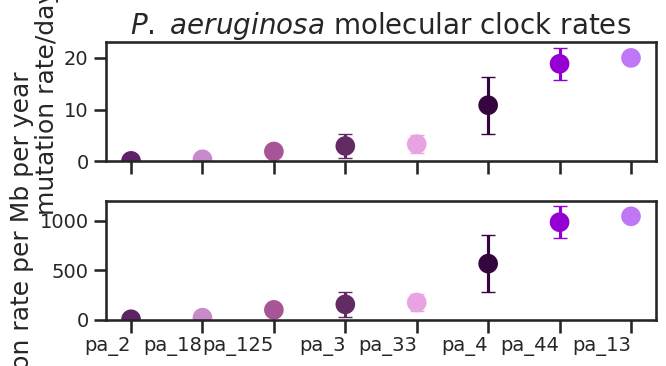

In [71]:
plot_snps_rates(pa_clockrates, save_path="../../out/figures/", file_name="unfiltered_clockrates_pa")

  dataset_prefix  mean_snps_day  std_snps_day  mean_snps_Mb_year  \
2           pa_2       0.073329      0.059210           3.823560   
1          pa_18       0.378256      0.049675          19.723339   
0         pa_125       1.889524      0.321426          98.525187   
3           pa_3       2.955346      2.408607         154.100191   
4          pa_33       3.312607      1.672313         172.728789   
5           pa_4       5.526980      2.444005         288.192523   

   std_snps_Mb_year  
2          3.087386  
1          2.590177  
0         16.760080  
3        125.591629  
4         87.199186  
5        127.437397  


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

Plot saved to ../../out/figures/filtered_clockrates_pa.png and ../../out/figures/filtered_clockrates_pa.svg


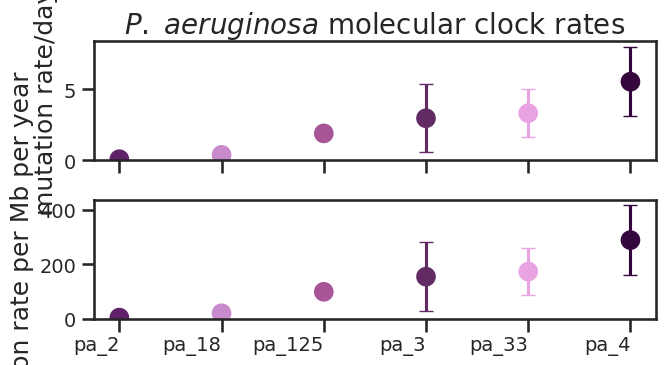

In [72]:
plot_snps_rates(filtered_df, save_path="../../out/figures/", file_name="filtered_clockrates_pa")

In [73]:
def plot_filtered_snps_histogram(filtered_df, outliers_df, snps_column="snps/day",
                                save_path=None, file_name=""):
    """Plots a histogram of SNPs per day, showing both passing and filtered SNPs,
    with a fitted Poisson distribution curve scaled to a secondary y-axis."""
    fig, ax1 = plt.subplots(figsize=(8, 5))
    
    # Combine both datasets to ensure proper bin alignment
    all_snps = pd.concat([filtered_df[snps_column], outliers_df[snps_column]])
    
    # Define bins to ensure consistency between both histograms (increase bin count for better resolution)
    bins = np.histogram_bin_edges(all_snps, bins=15)
    
    # Plot histogram with different colors for passing and filtered SNPs
    sns.histplot(filtered_df[snps_column], bins=bins, color="blue", label="Passing SNPs", alpha=0.7, edgecolor=None, ax=ax1)
    sns.histplot(outliers_df[snps_column], color="red", label="Filtered SNPs", alpha=0.7, edgecolor=None, ax=ax1)
    
    # Create secondary axis for Poisson fit
    ax2 = ax1.twinx()
    
    # Fit and plot a Poisson distribution line over all SNP data
    lambda_poisson = np.mean(all_snps)
    x_values = np.arange(0, int(max(all_snps)) + 1)
    poisson_pmf = stats.poisson.pmf(x_values, lambda_poisson)
    
    ax2.plot(x_values, poisson_pmf, color="lightgrey", linewidth=2, label="Poisson Fit")
    ax2.set_ylabel("Poisson Probability", fontsize=18)
    ax2.tick_params(axis='y', labelsize=14)
    
    ax1.set_xlabel("SNPs per day", fontsize=18)
    ax1.set_ylabel("Frequency", fontsize=18)
    ax1.tick_params(axis='both', labelsize=14)
    ax1.set_title("Distribution of SNPs per day (Passing vs. Filtered)", fontsize=18)
    
    # Set legend face color to white
    legend = ax1.legend()
    legend.get_frame().set_facecolor("white")
    
    ax1.text(0.6, 0.65, "95% Poisson distribution", transform=ax1.transAxes, fontsize=12, color="black")
    
    ax1.grid(False)
    ax1.set_ylim(0, None)  # Set primary y-axis to start at 0
    ax2.set_ylim(0, None)  # Set secondary y-axis to start at 0
    
    plt.tight_layout()

    if save_path:
        os.makedirs(save_path, exist_ok=True)
        png_path = os.path.join(save_path, f"{file_name}.png")
        svg_path = os.path.join(save_path, f"{file_name}.svg")
        plt.savefig(png_path, dpi=150, bbox_inches='tight')
        plt.savefig(svg_path, dpi=150, bbox_inches='tight')
        print(f"Plot saved to {png_path} and {svg_path}")
        
    plt.show();

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

Plot saved to ../../out/figures/filtered_snps_pa.png and ../../out/figures/filtered_snps_pa.svg


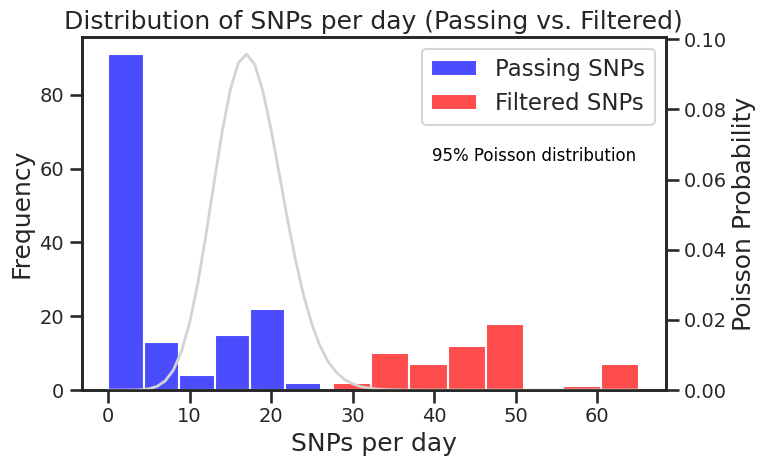

In [74]:
filtered_df, outliers_df = filter_outliers_poisson(pa_clockrates, "snps/day")
plot_filtered_snps_histogram(filtered_df, outliers_df,
                            save_path="../../out/figures/", file_name="filtered_snps_pa")